In [40]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import sklearn.linear_model
from matplotlib import pyplot as plt
from sklearn.impute import SimpleImputer

/var/folders/8z/376s2y0j745g6pvnn0hpw6140000gn/T/ipykernel_37400/2366273435.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


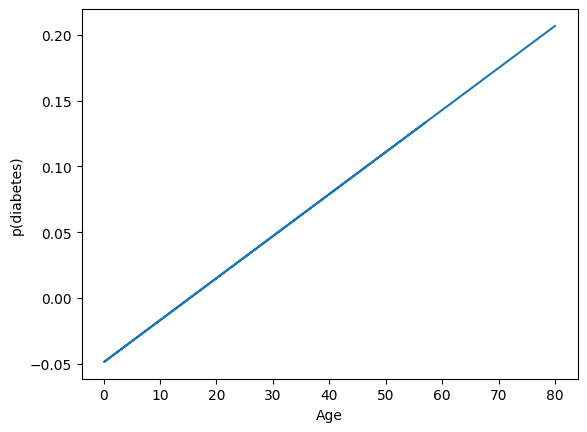

In [41]:



diabetes_model = sklearn.linear_model.LogisticRegression()
simple_regress = sklearn.linear_model.LinearRegression()

diabetes_df = pd.read_csv("datasets/diabetes.csv")
simple_regress.fit(diabetes_df[["age"]],diabetes_df[["diabetes"]])
y_pred=simple_regress.predict(diabetes_df[["age"]])
fig, ax = plt.subplots()
ax.plot(diabetes_df["age"], y_pred)
ax.set_xlabel("Age")
ax.set_ylabel("p(diabetes)")
fig.show()

In [42]:
diabetes_df=diabetes_df.drop("smoking_history",axis=1)
diabetes_df["gender"]=diabetes_df["gender"].map(lambda x: "0" if x=="Male" else "1" if x=="Female" else 0.5,)
cts_vars=["age","bmi","HbA1c_level", "blood_glucose_level"]
scaler=preprocessing.StandardScaler().fit(diabetes_df[cts_vars])
diabetes_df[cts_vars]=scaler.transform(diabetes_df[cts_vars])
diabetes_x=diabetes_df[list(diabetes_df.columns)[:-1]]
diabetes_y=diabetes_df["diabetes"]
diabetes_model=diabetes_model.fit(diabetes_x,diabetes_y)

In [43]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import sklearn.linear_model

heart_model = sklearn.linear_model.LogisticRegression()
heart_df = pd.read_csv("datasets/heart_disease.csv")
float_cols=[]
binary_cols=[]
for col in heart_df.columns:
    if type(heart_df[col].iloc[0])==np.float64:
        heart_df[col]=preprocessing.StandardScaler().fit_transform(heart_df[[col]])
    elif set(heart_df[col].unique())==set(["Yes","No"]):
        heart_df[col]=heart_df[col].map(lambda x: 1 if x=="Yes" else 0)
heart_df["Sex"]=heart_df["Sex"].map(lambda x: 1 if x=="Male" else 0)
age_cats=['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59', '60-64' ,'65-69','70-74','75-79','80 or older']
health_cats=["Poor","Fair","Good","Very good","Excellent"]
heart_df["GenHealth"]=heart_df["GenHealth"].map(health_cats.index)
heart_df["AgeCategory"]=heart_df["AgeCategory"].map(age_cats.index)
for race in ['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']:
    heart_df[race+" race"] = heart_df["Race"].map(lambda x:1 if x==race else 0)
heart_df.drop(columns=["Race"],inplace=True)
heart_df["Diabetic"]=heart_df["Diabetic"].map(lambda x:{"Yes":1,"No":0,"No, borderline diabetes":0.5,"Yes (during pregnancy)":1}[x])
heart_x=heart_df[list(heart_df.columns)[:-1]]
heart_y=heart_df["HeartDisease"]
heart_model.fit(heart_x,heart_y)

LogisticRegression()

In [53]:
stroke_model = sklearn.linear_model.LogisticRegression()
stroke_df = pd.read_csv("datasets/stroke.csv")

stroke_df.drop(columns=["id", "work_type","ever_married"],inplace=True)
stroke_df["gender"]=stroke_df["gender"].map(lambda x: 0 if x=="Female" else 1 if x=="Male" else 0.5)
stroke_df["Residence_type"]=stroke_df["Residence_type"].map(lambda x : 0 if x=="Rural" else 1)
stroke_df["avg_glucose_level"]=preprocessing.StandardScaler().fit_transform(stroke_df[["avg_glucose_level"]])
stroke_df["bmi"]=preprocessing.StandardScaler().fit_transform(stroke_df[["bmi"]])
stroke_df["age"]=preprocessing.StandardScaler().fit_transform(stroke_df[["age"]])
stroke_df["ever_smoked"]=stroke_df["smoking_status"].map(lambda x: np.nan if x=='Unknown' else 1 if x=="smokes" or x=="formerly smokes" else 0)
stroke_df["current_smoker"]=stroke_df["smoking_status"].map(lambda x: np.nan if x=='Unknown' else 1 if x=="smokes" else 0)
stroke_df.drop(columns=["smoking_status"], inplace=True)
stroke_df[:]=SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(stroke_df)
stroke_x=stroke_df[[col for col in stroke_df.columns if col!="stroke"]]
stroke_y=stroke_df["stroke"]
stroke_model.fit(stroke_x,stroke_y)
display(stroke_model.predict_proba(stroke_x))


array([[0.83119984, 0.16880016],
       [0.92798901, 0.07201099],
       [0.78625213, 0.21374787],
       ...,
       [0.99215885, 0.00784115],
       [0.96645997, 0.03354003],
       [0.98326973, 0.01673027]])

0         0
1         0
2         0
3         0
4         0
         ..
319790    1
319791    0
319792    0
319793    0
319794    0
Name: HeartDisease, Length: 319795, dtype: int64

In [48]:
import pandas as pd
from sklearn import preprocessing
import sklearn.linear_model

alzheimers_model = sklearn.linear_model.LogisticRegression()
alzheimers_df = pd.read_csv("datasets/alzheimers.csv")

alzheimers_df.drop(columns=["DoctorInCharge","PatientID"],inplace=True)
cols_to_scale = filter(lambda col : type(alzheimers_df[col].iloc[0])==np.float64 
                       or set(alzheimers_df[col].unique())!=set([0,1]),alzheimers_df.columns)
for col in cols_to_scale:
    alzheimers_df[col]=preprocessing.StandardScaler().fit_transform(alzheimers_df[[col]])
alzheimers_x=alzheimers_df[alzheimers_df.columns[:-1]]
alzheimers_y=alzheimers_df["Diagnosis"]
alzheimers_model.fit(alzheimers_x,alzheimers_y)

LogisticRegression()

In [51]:
def predict_premium(model, cost_per_disease, customers, markup):
    return [(1+markup)*cost_per_disease*disease_p for disease_p in model.predict_proba(customers)[:,1]]
predict_premium(alzheimers_model,1000,alzheimers_x,0.2)

[np.float64(155.82962575962276),
 np.float64(89.71351866119113),
 np.float64(67.78704403365424),
 np.float64(176.94584363284022),
 np.float64(620.341117418281),
 np.float64(5.0008956067844155),
 np.float64(57.686853321755954),
 np.float64(536.8075359407384),
 np.float64(672.2499671855468),
 np.float64(838.131693670996),
 np.float64(49.61557228141066),
 np.float64(47.41447862821499),
 np.float64(425.2528114841611),
 np.float64(1064.7306937677374),
 np.float64(88.53034114614411),
 np.float64(535.5404690089196),
 np.float64(859.3499899901129),
 np.float64(415.15881852856836),
 np.float64(45.23567112032159),
 np.float64(1027.2403713211665),
 np.float64(1062.05028620358),
 np.float64(943.893140191831),
 np.float64(109.57646173810642),
 np.float64(310.4179229471979),
 np.float64(1196.6949053277751),
 np.float64(10.777558024806039),
 np.float64(59.636236674370444),
 np.float64(137.86193397807872),
 np.float64(336.8574034204141),
 np.float64(46.50910380364812),
 np.float64(973.1621004489597),
